# Lựa chọn đặc trưng bằng RFE

Notebook này dùng phương pháp Recursive Feature Elimination để tìm số lượng đặc trưng phù hợp cho bài toán dự đoán tuổi Abalone.

## 1. Import thư viện

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
np.random.seed(42)

## 2. Nạp dữ liệu

In [ ]:
đường_dẫn_ứng_viên = [
    Path("../../data/raw/abalone.csv"),
    Path("../data/raw/abalone.csv"),
    Path("data/raw/abalone.csv"),
    Path("AbaloneAge/data/raw/abalone.csv"),
]

đường_dẫn_dữ_liệu = None
for p in đường_dẫn_ứng_viên:
    p_đầy_đủ = p.resolve()
    if p_đầy_đủ.exists():
        đường_dẫn_dữ_liệu = p_đầy_đủ
        break

if đường_dẫn_dữ_liệu is None:
    raise FileNotFoundError(
        "Không tìm thấy file abalone.csv. Đã thử: "
        + ", ".join(str(p.resolve()) for p in đường_dẫn_ứng_viên)
    )

df = pd.read_csv(đường_dẫn_dữ_liệu, header=None)
df.columns = [
    "sex",
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
    "rings",
]

print("Đường dẫn dữ liệu:", đường_dẫn_dữ_liệu)
print("Kích thước:", df.shape)
df.head()

Duong dan du lieu: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\data\raw\abalone.csv
Kich thuoc: (4177, 9)


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Chia train, validation, test

In [3]:
X = df.drop(columns=["rings"])
y = df["rings"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2923, 8) (2923,)
Validation: (627, 8) (627,)
Test: (627, 8) (627,)


## 4. Tiền xử lý

In [ ]:
cột_số = [
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
]
cột_hạng_mục = ["sex"]

biến_đổi_số = Pipeline(steps=[
    ("dien_khuyet", SimpleImputer(strategy="median")),
    ("chuan_hoa", StandardScaler()),
])

biến_đổi_hạng_mục = Pipeline(steps=[
    ("dien_khuyet", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

tiền_xử_lý = ColumnTransformer(transformers=[
    ("so", biến_đổi_số, cột_số),
    ("hang_muc", biến_đổi_hạng_mục, cột_hạng_mục),
])

X_train_txl = tiền_xử_lý.fit_transform(X_train)
X_val_txl = tiền_xử_lý.transform(X_val)
X_test_txl = tiền_xử_lý.transform(X_test)

tên_đặc_trưng = tiền_xử_lý.get_feature_names_out()
tổng_số_đặc_trưng = len(tên_đặc_trưng)
print("Tổng số đặc trưng sau tiền xử lý:", tổng_số_đặc_trưng)

Tong so dac trung sau tien xu ly: 10


## 5. Thử nghiệm nhiều giá trị số đặc trưng với RFE

In [ ]:
# Chọn các mốc n_features để tránh chạy quá chậm
d_s_n = sorted(set([3, 5, 7, 9, 10, min(12, tổng_số_đặc_trưng), tổng_số_đặc_trưng]))
kết_quả = []

for n in d_s_n:
    bộ_chọn = RFE(estimator=Ridge(alpha=1.0), n_features_to_select=n, step=1)
    bộ_chọn.fit(X_train_txl, y_train)

    X_train_rfe = bộ_chọn.transform(X_train_txl)
    X_val_rfe = bộ_chọn.transform(X_val_txl)

    mô_hình = Ridge(alpha=1.0)
    mô_hình.fit(X_train_rfe, y_train)
    dự_đoán_val = mô_hình.predict(X_val_rfe)

    mae = mean_absolute_error(y_val, dự_đoán_val)
    rmse = np.sqrt(mean_squared_error(y_val, dự_đoán_val))
    r2 = r2_score(y_val, dự_đoán_val)

    kết_quả.append({
        "số_đặc_trưng": int(n),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

bảng_kết_quả = pd.DataFrame(kết_quả).sort_values(by="RMSE")
bảng_kết_quả

,so_dac_trung,MAE,RMSE,R2
3,9,1.620118,2.223586,0.507188
4,10,1.620732,2.224273,0.506883
2,7,1.622409,2.225317,0.506420
1,5,1.656776,2.259461,0.491157
0,3,1.728551,2.326402,0.460560


## 6. Biểu đồ hiệu năng theo số đặc trưng

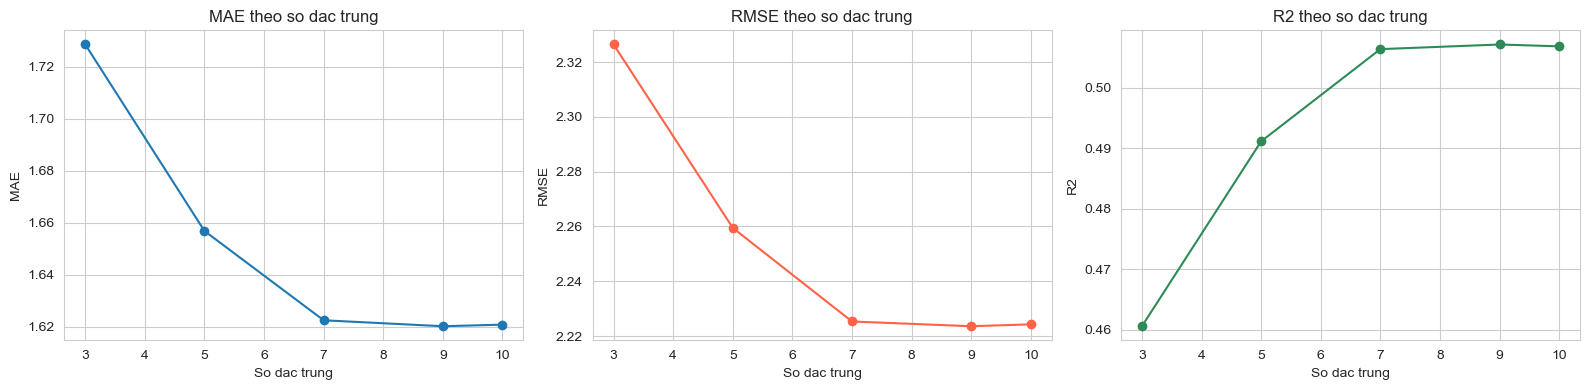

Da luu hinh: 03_feature_selection_rfe_metrics.png


In [ ]:
bảng_plot = bảng_kết_quả.sort_values(by="số_đặc_trưng")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(bảng_plot["số_đặc_trưng"], bảng_plot["MAE"], marker="o")
axes[0].set_title("MAE theo số đặc trưng")
axes[0].set_xlabel("Số đặc trưng")
axes[0].set_ylabel("MAE")

axes[1].plot(bảng_plot["số_đặc_trưng"], bảng_plot["RMSE"], marker="o", color="tomato")
axes[1].set_title("RMSE theo số đặc trưng")
axes[1].set_xlabel("Số đặc trưng")
axes[1].set_ylabel("RMSE")

axes[2].plot(bảng_plot["số_đặc_trưng"], bảng_plot["R2"], marker="o", color="seagreen")
axes[2].set_title("R2 theo số đặc trưng")
axes[2].set_xlabel("Số đặc trưng")
axes[2].set_ylabel("R2")

plt.tight_layout()
đường_dẫn_hình = Path("../../outputs/figures").resolve()
đường_dẫn_hình.mkdir(parents=True, exist_ok=True)
plt.savefig(đường_dẫn_hình / "03_feature_selection_rfe_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu hình: 03_feature_selection_rfe_metrics.png")

## 7. Chọn cấu hình tốt nhất và xem đặc trưng được giữ

In [ ]:
n_tốt_nhất = int(bảng_kết_quả.iloc[0]["số_đặc_trưng"])
print("Số đặc trưng tốt nhất theo RMSE:", n_tốt_nhất)

bộ_chọn_tốt_nhất = RFE(estimator=Ridge(alpha=1.0), n_features_to_select=n_tốt_nhất, step=1)
bộ_chọn_tốt_nhất.fit(X_train_txl, y_train)

bộ_lọc = bộ_chọn_tốt_nhất.support_
xếp_hạng = bộ_chọn_tốt_nhất.ranking_

bảng_xếp_hạng = pd.DataFrame({
    "đặc_trưng": tên_đặc_trưng,
    "được_chọn": bộ_lọc,
    "xếp_hạng_rfe": xếp_hạng,
}).sort_values(by=["xếp_hạng_rfe", "đặc_trưng"])

bảng_xếp_hạng.head(20)

So dac trung tot nhat theo RMSE: 9


,dac_trung,duoc_chon,xep_hang_rfe
7,hang_muc__sex_F,True,1
8,hang_muc__sex_I,True,1
9,hang_muc__sex_M,True,1
1,so__diameter,True,1
2,so__height,True,1
6,so__shell_weight,True,1
4,so__shucked_weight,True,1
5,so__viscera_weight,True,1
3,so__whole_weight,True,1
0,so__length,False,2


## 8. Đánh giá trên tập test

In [ ]:
X_train_tốt = bộ_chọn_tốt_nhất.transform(X_train_txl)
X_test_tốt = bộ_chọn_tốt_nhất.transform(X_test_txl)

mô_hình_tốt = Ridge(alpha=1.0)
mô_hình_tốt.fit(X_train_tốt, y_train)
dự_đoán_test = mô_hình_tốt.predict(X_test_tốt)

mae_test = mean_absolute_error(y_test, dự_đoán_test)
rmse_test = np.sqrt(mean_squared_error(y_test, dự_đoán_test))
r2_test = r2_score(y_test, dự_đoán_test)

print(f"MAE test : {mae_test:.4f}")
print(f"RMSE test: {rmse_test:.4f}")
print(f"R2 test  : {r2_test:.4f}")

MAE test : 1.5455
RMSE test: 2.1456
R2 test  : 0.5515


## 9. Lưu kết quả

In [ ]:
đường_dẫn_metrics = Path("../../outputs/metrics").resolve()
đường_dẫn_metrics.mkdir(parents=True, exist_ok=True)

bảng_kết_quả.to_csv(đường_dẫn_metrics / "03_rfe_n_features_comparison.csv", index=False)
bảng_xếp_hạng.to_csv(đường_dẫn_metrics / "03_rfe_feature_ranking.csv", index=False)

tóm_tắt = {
    "phương_pháp": "rfe",
    "số_đặc_trưng_tốt_nhất": n_tốt_nhất,
    "test": {
        "MAE": mae_test,
        "RMSE": rmse_test,
        "R2": r2_test,
    },
    "top_10": bảng_xếp_hạng.query("được_chọn == True").head(10).to_dict(orient="records"),
}

with open(đường_dẫn_metrics / "03_rfe_summary.json", "w", encoding="utf-8") as f:
    json.dump(tóm_tắt, f, ensure_ascii=False, indent=2)

print("Đã lưu: 03_rfe_n_features_comparison.csv")
print("Đã lưu: 03_rfe_feature_ranking.csv")
print("Đã lưu: 03_rfe_summary.json")

Da luu: 03_rfe_n_features_comparison.csv
Da luu: 03_rfe_feature_ranking.csv
Da luu: 03_rfe_summary.json
